In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

In [26]:
df=pd.read_csv('day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [27]:
df.shape

(730, 16)

In [28]:
df['dteday'] = pd.to_datetime(df['dteday'], dayfirst=True)
df['is_weekend'] = (df['weekday'] >= 5).astype(int)
df = df.drop('dteday', axis=1)
df = df.drop(['instant','casual','registered'], axis=1)
df = df.drop('atemp', axis=1)

In [29]:
df = pd.get_dummies(df, columns=['season','mnth','weekday','weathersit'], drop_first=True)

In [30]:
X = df.drop('cnt', axis=1)
Y = df['cnt']

In [31]:
vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
1,holiday,inf
2,workingday,inf
6,is_weekend,inf
27,weekday_5,inf
28,weekday_6,inf
25,weekday_3,inf
26,weekday_4,inf
23,weekday_1,inf
24,weekday_2,inf
3,temp,117.708576


In [32]:
X = X.drop(columns=['temp_hum','windspeed_sq'], errors='ignore')

In [33]:
vif1 = pd.DataFrame()
vif1["Feature"] = X.columns
vif1["VIF"] = [
    variance_inflation_factor(X.values.astype(float), i)
    for i in range(X.shape[1])
]

vif1.sort_values("VIF", ascending=False)

,Feature,VIF
1,holiday,inf
2,workingday,inf
6,is_weekend,inf
23,weekday_3,inf
24,weekday_4,inf
25,weekday_5,inf
26,weekday_6,inf
21,weekday_1,inf
22,weekday_2,inf
3,temp,56.333149


In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [35]:
pipeline=Pipeline([
    ('Scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

In [38]:
param_grid = {
    'knn__n_neighbors': list(range(1, 41)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, Y_train)
grid.best_params_

{'knn__n_neighbors': 12, 'knn__p': 1, 'knn__weights': 'distance'}

In [39]:
best_model=grid.best_estimator_
Y_pred=best_model.predict(X_test)

mse=mean_squared_error(Y_test, Y_pred)
rmse=np.sqrt(mse)
r2=r2_score(Y_test, Y_pred)

print(f"MSE: {mse:2f}")
print(f"RMSE: {rmse:2f}")
print(f"R2 score: {r2:3f}")

MSE: 959375.866466
RMSE: 979.477344
R2 score: 0.719714


In [40]:
cv_results=pd.DataFrame(grid.cv_results_)
cv_results['RMSE']=np.sqrt(-cv_results['mean_test_score'])
rmse_k=cv_results.groupby('param_knn__n_neighbors')['RMSE'].mean()
best_k=rmse_k.idxmin()
best_rmse=rmse_k.min()

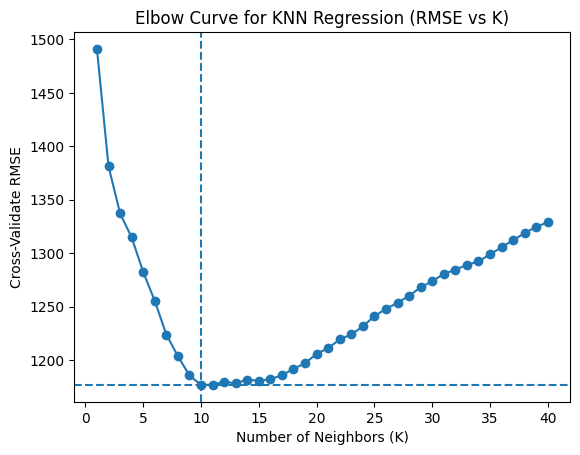

np.int64(10)

In [41]:
plt.figure()
plt.plot(rmse_k.index, rmse_k.values, marker='o')
plt.axvline(best_k, linestyle='--')
plt.axhline(best_rmse, linestyle='--')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Cross-Validate RMSE")
plt.title("Elbow Curve for KNN Regression (RMSE vs K)")
plt.show()
best_k